In [1]:
import os
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/subihanbiswas/iitd-iris-split/iris_train.csv")
val_df = pd.read_csv("/kaggle/input/datasets/subihanbiswas/iitd-iris-split/iris_val.csv")
test_df = pd.read_csv("/kaggle/input/datasets/subihanbiswas/iitd-iris-split/iris_test.csv")

In [3]:
ROOT_DIR = "/kaggle/input/datasets/subihanbiswas/iitd-iris-dataset/IITD_database"

In [4]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomRotation(5),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.03,0.03),
        scale=(0.95,1.05)
    ),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.GaussianBlur(
        kernel_size=3
    ),

    transforms.ToTensor(),

    transforms.RandomErasing(
        p=0.3,
        scale=(0.02,0.1)
    ),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [5]:
val_test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [6]:
class IITDIrisDataset(Dataset):

    def __init__(
        self,
        dataframe,
        root_dir,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)

        self.root_dir = root_dir

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = os.path.join(
            self.root_dir,
            row["image_path"]
        )

        image = Image.open(image_path).convert("RGB")

        label = int(row["class_id"])

        if self.transform:

            image = self.transform(image)

        return image, label

In [7]:
train_dataset = IITDIrisDataset(
    dataframe=train_df,
    root_dir=ROOT_DIR,
    transform=train_transform
)

val_dataset = IITDIrisDataset(
    dataframe=val_df,
    root_dir=ROOT_DIR,
    transform=val_test_transform
)

test_dataset = IITDIrisDataset(
    dataframe=test_df,
    root_dir=ROOT_DIR,
    transform=val_test_transform
)

In [8]:
BATCH_SIZE = 32

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [10]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

1428
204
408


In [11]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [12]:
print(labels)

tensor([112, 170, 177, 143,  72, 123,  94, 107,  29,  70,  17, 152, 159, 190,
        107,  72,  27, 125,  92, 135, 164, 146, 199,  30, 151, 161, 100, 123,
         89, 171,  34, 185])


In [13]:
!pip install timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.0 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [14]:
import timm

print(timm.__version__)

1.0.26


In [15]:
import timm
import torch
import torch.nn as nn

In [16]:
model = timm.create_model(
    "convnextv2_tiny.fcmae_ft_in22k_in1k",
    pretrained=True,
    num_classes=0
)

print(model)

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (mlp): GlobalResponseNormMlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (grn): GlobalResponseNorm()
            (fc2): Linear(in_features=384, out_features=96, bias=True)
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), 

In [17]:
import timm

backbone = timm.create_model(
    "convnextv2_tiny.fcmae_ft_in22k_in1k",
    pretrained=True,
    num_classes=0
)

In [18]:
dummy = torch.randn(2,3,224,224)

with torch.no_grad():
    features = backbone(dummy)

print(features.shape)

torch.Size([2, 768])


In [19]:
# import torch.nn as nn


# class IrisConvNextV2(nn.Module):

#     def __init__(
#             self,
#             backbone,
#             num_classes=204):

#         super().__init__()

#         self.backbone = backbone

#         self.classifier = nn.Sequential(

#             nn.Linear(768, 1024),

#             nn.BatchNorm1d(1024),

#             nn.GELU(),

#             nn.Dropout(0.5),

#             nn.Linear(1024, 512),

#             nn.BatchNorm1d(512),

#             nn.GELU(),

#             nn.Dropout(0.3),

#             nn.Linear(512, num_classes)

#         )

#     def forward(self, x):

#         features = self.backbone(x)

#         logits = self.classifier(features)

#         return logits

In [20]:
import torch.nn.functional as F

In [21]:
class IrisConvNextV2(nn.Module):

    def __init__(self, backbone, num_classes=204):

        super().__init__()

        self.backbone = backbone

        # Embedding head
        self.embedding_head = nn.Sequential(

            nn.Linear(768, 1024),

            nn.BatchNorm1d(1024),

            nn.GELU(),

            nn.Dropout(0.5),

            nn.Linear(1024, 512),

            nn.BatchNorm1d(512),

            nn.GELU(),

            nn.Dropout(0.3)

        )

        # Classification head
        self.classifier = nn.Linear(
            512,
            num_classes
        )

    
    def forward(self, x):

        features = self.backbone(x)
    
        # Raw embedding
        embedding = self.embedding_head(features)
    
        # Classification uses raw embedding
        logits = self.classifier(embedding)
    
        # For feature extraction / multimodal fusion
        normalized_embedding = F.normalize(
            embedding,
            p=2,
            dim=1
        )
    
        return logits, normalized_embedding

In [22]:
model = IrisConvNextV2(
    backbone=backbone,
    num_classes=204
)

In [23]:
for param in model.parameters():
    param.requires_grad = True

In [24]:
# device = torch.device(
#     "cuda" if torch.cuda.is_available()
#     else "cpu"
# )

# print(
#     f"GPUs available: {torch.cuda.device_count()}"
# )

# # if torch.cuda.device_count() > 1:

# #     print(
# #         f"Using DataParallel across {torch.cuda.device_count()} GPUs"
# #     )

# #     model = nn.DataParallel(model)

# model = model.to(device)

In [25]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device: {device}")

model = model.to(device)

Using device: cuda


In [26]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params: 29,286,476
Trainable params: 29,286,476


In [27]:
!pip install torchinfo

In [28]:
from torchinfo import summary

summary(
    model,
    input_size=(32, 3, 224, 224),
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "trainable"
    ]
)

Layer (type:depth-idx)                                            Input Shape               Output Shape              Param #                   Trainable
IrisConvNextV2                                                    [32, 3, 224, 224]         [32, 204]                 --                        True
├─ConvNeXt: 1-1                                                   [32, 3, 224, 224]         [32, 768]                 --                        True
│    └─Sequential: 2-1                                            [32, 3, 224, 224]         [32, 96, 56, 56]          --                        True
│    │    └─Conv2d: 3-1                                           [32, 3, 224, 224]         [32, 96, 56, 56]          4,704                     True
│    │    └─LayerNorm2d: 3-2                                      [32, 96, 56, 56]          [32, 96, 56, 56]          192                       True
│    └─Sequential: 2-2                                            [32, 96, 56, 56]          [32, 768,

In [29]:
criterion = nn.CrossEntropyLoss()

In [30]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-5,

    weight_decay=1e-4
)

In [31]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

In [32]:
scaler = torch.amp.GradScaler("cuda")

In [33]:

def train_one_epoch(
        model,
        loader,
        criterion,
        optimizer,
        scaler,
        device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, leave=False)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)
        

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            outputs, embedding  = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        pbar.set_postfix(
            loss=running_loss/total,
            acc=correct/total
        )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [34]:
@torch.no_grad()
def validate(
        model,
        loader,
        criterion,
        device
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        with torch.amp.autocast('cuda'):

            outputs, embedding  = model(images)

            loss = criterion(outputs, labels)

        running_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [35]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.amp.autocast('cuda'):
    outputs, embedding  = model(images)
    loss = criterion(outputs, labels)

print(outputs.requires_grad)
print(loss.requires_grad)

True
True


In [36]:
import matplotlib.pyplot as plt

def plot_history(history):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14,5))

    # Loss
    plt.subplot(1,2,1)

    plt.plot(
        epochs,
        history["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")

    plt.legend()

    plt.grid(True)

    # Accuracy
    plt.subplot(1,2,2)

    plt.plot(
        epochs,
        history["train_acc"],
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history["val_acc"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [37]:
from tqdm.auto import tqdm
import torch


def train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        scaler,
        device,
        initial_epochs=50,
        patience=10
):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    early_stop_counter = 0
    current_epoch = 0
    epochs_to_run = initial_epochs

    while True:

        for _ in range(epochs_to_run):

            current_epoch += 1

            # ==========================
            # Training
            # ==========================
            train_loss, train_acc = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                scaler,
                device
            )

            # ==========================
            # Validation
            # ==========================
            val_loss, val_acc = validate(
                model,
                val_loader,
                criterion,
                device
            )

            # ==========================
            # Scheduler
            # ==========================
            scheduler.step(val_acc)

            # ==========================
            # Save history
            # ==========================
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            # ==========================
            # Print epoch results
            # ==========================
            print(
                f"Epoch [{current_epoch}] "
                f"| Train Loss: {train_loss:.4f}"
                f" | Train Acc: {train_acc:.4f}"
                f" | Val Loss: {val_loss:.4f}"
                f" | Val Acc: {val_acc:.4f}"
            )

            # ==========================
            # Save best model
            # ==========================
            if val_acc > best_val_acc:

                best_val_acc = val_acc
                early_stop_counter = 0

                torch.save(
                    model.state_dict(),
                    "best_model.pth"
                )
                # torch.save(
                #     (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()),
                #     "best_model.pth"
                # )
                

                print(
                    f"Best model saved! "
                    f"(Val Acc = {best_val_acc:.4f})"
                )

            else:

                early_stop_counter += 1

            # ==========================
            # Save last model
            # ==========================
            
            torch.save(
                model.state_dict(),
                "last_model.pth"
            )
            # torch.save(
            #     (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()),
            #     "last_model.pth"
            # )

            # ==========================
            # Early stopping
            # ==========================
            if early_stop_counter >= patience:

                print("\nEarly stopping triggered!")

                return history, best_val_acc

        # =====================================
        # Ask whether to continue training
        # =====================================
        answer = input(
            "\nContinue training? (y/n): "
        ).lower()

        if answer != "y":

            print("\nTraining finished.")

            break

        epochs_to_run = int(
            input(
                "How many more epochs? "
            )
        )

    # return history, best_val_acc
    plot_history(history)

    return history, best_val_acc

In [38]:
history, best_val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    initial_epochs=20,
    patience=10
)

  0%|          | 0/45 [00:00<?, ?it/s]

Epoch [1] | Train Loss: 5.3704 | Train Acc: 0.0042 | Val Loss: 5.3069 | Val Acc: 0.0147
Best model saved! (Val Acc = 0.0147)


  0%|          | 0/45 [00:00<?, ?it/s]

Epoch [2] | Train Loss: 5.3154 | Train Acc: 0.0028 | Val Loss: 5.2390 | Val Acc: 0.0196
Best model saved! (Val Acc = 0.0196)


  0%|          | 0/45 [00:00<?, ?it/s]

...

Epoch [47] | Train Loss: 2.5810 | Train Acc: 0.9671 | Val Loss: 2.5350 | Val Acc: 1.0000


  0%|          | 0/45 [00:00<?, ?it/s]

Epoch [48] | Train Loss: 2.5624 | Train Acc: 0.9720 | Val Loss: 2.4836 | Val Acc: 1.0000


  0%|          | 0/45 [00:00<?, ?it/s]

Epoch [49] | Train Loss: 2.5683 | Train Acc: 0.9706 | Val Loss: 2.5206 | Val Acc: 1.0000

Early stopping triggered!


In [39]:
import torch
import numpy as np
from tqdm.auto import tqdm


@torch.no_grad()
def test_model(
        model,
        test_loader,
        criterion,
        device
):

    model.eval()

    running_loss = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    pbar = tqdm(test_loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        with torch.amp.autocast('cuda'):

            outputs, embedding = model(images)

            loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * labels.size(0)

        total += labels.size(0)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

    test_loss = running_loss / total

    return (
        test_loss,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

In [40]:
from sklearn.metrics import (
    accuracy_score,
    top_k_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt


def evaluate_metrics(
        test_loss,
        all_labels,
        all_preds,
        all_probs
):

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    top3_acc = top_k_accuracy_score(
        all_labels,
        all_probs,
        k=3
    )

    top5_acc = top_k_accuracy_score(
        all_labels,
        all_probs,
        k=5
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    report = classification_report(
        all_labels,
        all_preds
    )

    print("="*50)
    print(f"Test Loss      : {test_loss:.4f}")
    print(f"Top-1 Accuracy : {accuracy:.4f}")
    print(f"Top-3 Accuracy : {top3_acc:.4f}")
    print(f"Top-5 Accuracy : {top5_acc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print("="*50)

    print("\nClassification Report:\n")

    print(report)

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        cmap='Blues'
    )

    plt.title("Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.show()

    results = {

        "test_loss": test_loss,

        "accuracy": accuracy,

        "top3_accuracy": top3_acc,

        "top5_accuracy": top5_acc,

        "precision": precision,

        "recall": recall,

        "f1_score": f1,

        "confusion_matrix": cm,

        "classification_report": report

    }

    return results

  0%|          | 0/13 [00:00<?, ?it/s]

Test Loss      : 2.3355
Top-1 Accuracy : 0.9951
Top-3 Accuracy : 0.9975
Top-5 Accuracy : 0.9975
Precision      : 0.9967
Recall         : 0.9951
F1 Score       : 0.9948

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      0.50      0.67         2
          13       1.00      1.00      1.00       

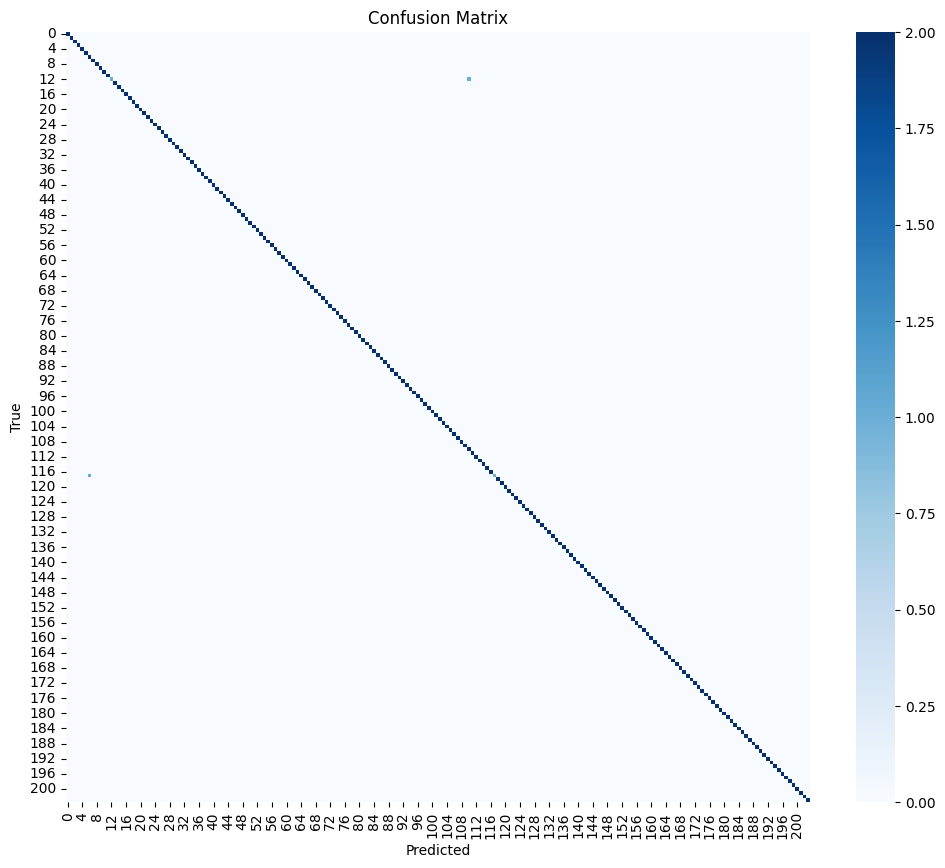

In [41]:
test_loss, labels, preds, probs = test_model(
    model,
    test_loader,
    criterion,
    device=device
)

results = evaluate_metrics(
    test_loss,
    labels,
    preds,
    probs
)

In [42]:
probs.max(axis=1).mean()

np.float16(0.1458)

In [43]:
probs.max(axis=1).min()

np.float16(0.01074)

In [44]:
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    logits, embedding = model(images)

print(logits.shape)
print(embedding.shape)

print(torch.softmax(logits, dim=1)[0].max())
print(torch.argmax(logits, dim=1)[:10])

torch.Size([32, 204])
torch.Size([32, 512])
tensor(0.0993, device='cuda:0')
tensor([0, 0, 1, 1, 2, 2, 3, 3, 4, 4], device='cuda:0')
